# Sound-Speed Uncertainty Product

This notebook is the OCEANS 2026 paper-support uncertainty build. It starts a
new path after notebook `5`: notebook `5` remains the deterministic model-build
artifact, while this notebook produces the figure-ready uncertainty table.

The output unit is one row per query point and target pressure/depth. The table
carries temperature and salinity point estimates, componentized T/S variances,
GSW/TEOS-10 sound-speed estimates, finite-difference sound-speed partial
derivatives, propagated sound-speed variances, support diagnostics, and 110 m
decomposition columns for paper figures.

In [1]:
from __future__ import annotations

import json
import pickle
import sys
import time
import tracemalloc
from itertools import product
from pathlib import Path

import importlib.metadata as importlib_metadata
import matplotlib.colors as mcolors
import matplotlib.patheffects as path_effects
import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
import cartopy
import cartopy.crs as ccrs
import cartopy.feature as cfeature
import matplotlib.ticker as mticker
from matplotlib.lines import Line2D
from mpl_toolkits.axes_grid1 import make_axes_locatable
from tqdm.auto import tqdm

from argo_interp.acoustics import (
    sound_speed_teos10,
    sound_speed_teos10_partials,
    sound_speed_variance,
)
from argo_interp.cycle.adapter import PchipAdapter
from argo_interp.cycle.config import ModelSettings
from argo_interp.cycle.domain import ModelData, ModelMeta
from argo_interp.cycle.model import Model
from argo_interp.data.data_filter import data_filter
from argo_interp.model import CycleModels

notebook_path_candidate = Path.cwd()
if not (notebook_path_candidate / "lib").exists():
    repo_relative_notebook_dir = Path("research/underwater-acoustics/notebooks")
    if (repo_relative_notebook_dir / "lib").exists():
        sys.path.insert(0, str(repo_relative_notebook_dir.resolve()))

from lib import (
    GaussianScale,
    WeightConfig,
    build_candidate_query,
    compute_weight_deltas,
    weighted_cycle_prediction,
    weighted_profile_variance,
    weighted_profile_mean,
)

## Configuration

The horizontal grid and target depths follow the notebook `5` model-build
defaults. The anchor date is fixed here for reproducibility. The current
weight configuration uses distance, absolute time, and wrapped seasonal
weighting.

In [2]:
notebook_dir = Path.cwd()
if not (notebook_dir / "lib").exists():
    notebook_dir = Path("research/underwater-acoustics/notebooks")

data_path = notebook_dir / "data"
chart_path = data_path / "charts"
cartopy_data_path = data_path / "cartopy"
data_path.mkdir(exist_ok=True, parents=True)
chart_path.mkdir(exist_ok=True, parents=True)
cartopy_data_path.mkdir(exist_ok=True, parents=True)
cartopy.config["data_dir"] = str(cartopy_data_path)

box = [
    80,
    99,
    6,
    23,
    0,
    750,
    "2011-01-01",
    "2020-12-31",
]

target_pressure = np.array([5.0, 35.0, 110.0, 500.0])
anchor_time = np.datetime64("2015-07-01")
analysis_date_label = str(anchor_time)

lat_resolution = 1e-1
lon_resolution = 1e-1
lat_array = np.arange(box[2], box[3] + lat_resolution, lat_resolution)
lon_array = np.arange(box[0], box[1] + lon_resolution, lon_resolution)
lat_lon_product = list(product(lat_array, lon_array))

distance_kernel_sigma_deg = 1.0 / 3.0
candidate_radius_sigma = 3.0
dist_rad = distance_kernel_sigma_deg * candidate_radius_sigma

seconds_per_year = 365.25 * 24 * 60 * 60
seconds_per_week = 7 * 24 * 60 * 60

year_stdev = 3.0
season_weeks = 8
season_week_stdev = 3.0

use_distance_weight = True
use_time_weight = True
use_season_weight = True

weight_config = WeightConfig(
    distance=GaussianScale(distance_kernel_sigma_deg),
    time=GaussianScale(year_stdev * seconds_per_year),
    season=GaussianScale.from_border(season_weeks * seconds_per_week, season_week_stdev),
    use_distance=use_distance_weight,
    use_time=use_time_weight,
    use_season=use_season_weight,
)

sensor_support_tau = 40.0

weighting_cache_metadata = {
    "anchor_time": str(anchor_time),
    "distance_kernel_sigma_deg": distance_kernel_sigma_deg,
    "candidate_radius_sigma": candidate_radius_sigma,
    "dist_rad": dist_rad,
    "year_stdev": year_stdev,
    "season_weeks": season_weeks,
    "season_week_stdev": season_week_stdev,
    "use_distance_weight": use_distance_weight,
    "use_time_weight": use_time_weight,
    "use_season_weight": use_season_weight,
    "sensor_support_tau": sensor_support_tau,
}

argo_data_path = data_path / "argo_data.pkl"
cycle_model_cache_path = data_path / "pchip_cycle_models.pkl"
spatial_variance_path = data_path / "sound_speed_uncertainty_spatial_variance.pkl"
spatial_variance_metadata_path = data_path / "sound_speed_uncertainty_spatial_variance_metadata.json"
uncertainty_product_path = data_path / "sound_speed_uncertainty_product.pkl"
uncertainty_product_metadata_path = data_path / "sound_speed_uncertainty_product_metadata.json"
uncertainty_product_csv_path = data_path / "sound_speed_uncertainty_product.csv"
uncertainty_product_110m_csv_path = data_path / "sound_speed_uncertainty_product_110m.csv"
uncertainty_depth_summary_csv_path = data_path / "sound_speed_uncertainty_depth_summary.csv"
benchmark_path = data_path / "sound_speed_uncertainty_benchmark.csv"
benchmark_metadata_path = data_path / "sound_speed_uncertainty_benchmark_metadata.json"


def cache_metadata_matches(metadata_path: Path, expected_metadata: dict[str, object]) -> bool:
    if not metadata_path.exists():
        return False
    with metadata_path.open() as f:
        return json.load(f) == expected_metadata


def write_cache_metadata(metadata_path: Path, metadata: dict[str, object]) -> None:
    with metadata_path.open("w") as f:
        json.dump(metadata, f, indent=2, sort_keys=True)
        f.write("\n")

## Load Argo Data When Rebuilding Cycle Models

The uncertainty product uses the cached PCHIP cycle-model bundle when present.
Raw Argo data is loaded only when that bundle must be rebuilt.

In [3]:
def load_filtered_argo_data():
    if argo_data_path.exists():
        with argo_data_path.open("rb") as f:
            ds = pickle.load(f)
    else:
        from argo_interp.data.get_data import get_data

        ds = get_data(box, progress=True)
        with argo_data_path.open("wb") as f:
            pickle.dump(ds, f)

    ds_filters = [
        ds["PRES_QC"].isin([1, 2]),
        ds["TEMP_QC"].isin([1, 2]),
        ds["PSAL_QC"].isin([1, 2]),
    ]
    return data_filter(ds, ds_filters)

## Build or Load Per-Cycle Models

The cached model bundle is specific to this notebook's PCHIP cycle model
backbone. Delete `data/pchip_cycle_models.pkl` to force a rebuild after model
or filtering changes.

In [4]:
settings = ModelSettings(n_folds=5)


def build_cycle_models(filtered_ds, model_settings):
    models = {}
    models_data = {}

    cycles = len(
        filtered_ds[["PLATFORM_NUMBER", "CYCLE_NUMBER", "DIRECTION"]]
        .to_dataframe()
        .drop_duplicates()
    )
    grouped = filtered_ds.groupby(["PLATFORM_NUMBER", "CYCLE_NUMBER", "DIRECTION"])

    for (platform_number, cycle_number, direction), cycle_ds in tqdm(grouped, total=cycles):
        pressure = cycle_ds["PRES"].values
        temperature = cycle_ds["TEMP"].values
        salinity = cycle_ds["PSAL"].values

        if cycle_ds.sizes["N_POINTS"] < 3:
            continue

        model_data = ModelData(
            pressure=pressure,
            temperature=temperature,
            salinity=salinity,
        ).clean_duplicates("mean")

        model_meta = ModelMeta(
            platform_number=str(int(platform_number)),
            cycle_number=str(int(cycle_number)),
            direction=direction,
            latitude=cycle_ds["LATITUDE"].values[0],
            longitude=cycle_ds["LONGITUDE"].values[0],
            timestamp=cycle_ds["TIME"].values[0],
            profile_pressure=(pressure.min(), pressure.max()),
        )

        model = Model.build(model_meta, model_data, PchipAdapter, model_settings)
        models[model_meta.cycle_id] = model
        models_data[model_meta.cycle_id] = model_data

    return CycleModels(models), models_data


if cycle_model_cache_path.exists():
    with cycle_model_cache_path.open("rb") as f:
        cycle_model_bundle = pickle.load(f)
    cycle_models = cycle_model_bundle["cycle_models"]
    models_data = cycle_model_bundle["models_data"]
else:
    ds = load_filtered_argo_data()
    cycle_models, models_data = build_cycle_models(ds, settings)
    with cycle_model_cache_path.open("wb") as f:
        pickle.dump({"cycle_models": cycle_models, "models_data": models_data}, f)

all_metadata = cycle_models.metadata()
len(all_metadata)

20986

## Spatial Variance Bucket

The per-cycle model variance covers vertical reconstruction within a cycle.
This section estimates the separate spatial interpolation bucket by predicting
each target cycle from neighboring cycles on the same target pressure grid.
The target values are the held-out cycle model values at those pressures, so
the residual primarily measures local-window interpolation rather than raw
vertical sampling noise.

In [5]:
def estimate_depthwise_spatial_variance(
    cycle_models: CycleModels,
    target_pressure: np.ndarray,
    weight_config: WeightConfig,
    dist_rad: float,
) -> pd.DataFrame:
    rows = []
    metadata = cycle_models.metadata()

    for position, cycle_id in enumerate(tqdm(metadata.cycle_id)):
        candidate_query = build_candidate_query(
            target_latitude=metadata.latitude[position],
            target_longitude=metadata.longitude[position],
            dist_rad=dist_rad,
            exclude_platform_number=metadata.platform_number[position],
        )
        candidate_mask = cycle_models.mask(**candidate_query.to_mask_kwargs())
        if candidate_mask.sum() == 0:
            continue

        candidate_metadata = cycle_models.metadata(candidate_mask)
        weight_deltas = compute_weight_deltas(
            target_latitude=metadata.latitude[position],
            target_longitude=metadata.longitude[position],
            target_timestamp=metadata.timestamp[position],
            candidate_metadata=candidate_metadata,
        )
        weights = weight_config.joint_weight(weight_deltas)

        target = cycle_models[cycle_id].interpolate(target_pressure)
        interpolates = cycle_models.interpolate(target_pressure, mask=candidate_mask)
        predicted_temperature, predicted_salinity = weighted_cycle_prediction(interpolates, weights)

        for depth_index, pressure in enumerate(target_pressure):
            target_temperature = target.temperature[depth_index]
            target_salinity = target.salinity[depth_index]
            predicted_temp = predicted_temperature[depth_index]
            predicted_sal = predicted_salinity[depth_index]

            if not np.isfinite([target_temperature, target_salinity, predicted_temp, predicted_sal]).all():
                continue

            rows.append(
                {
                    "cycle_id": cycle_id,
                    "pressure_dbar": pressure,
                    "temperature_residual": target_temperature - predicted_temp,
                    "salinity_residual": target_salinity - predicted_sal,
                }
            )

    residuals = pd.DataFrame(rows)
    depthwise = residuals.groupby("pressure_dbar").agg(
        var_temperature_spatial=("temperature_residual", "var"),
        var_salinity_spatial=("salinity_residual", "var"),
        spatial_validation_count=("cycle_id", "count"),
    )
    return depthwise.reindex(target_pressure)


spatial_variance_cache_valid = spatial_variance_path.exists() and cache_metadata_matches(
    spatial_variance_metadata_path,
    weighting_cache_metadata,
)

if spatial_variance_cache_valid:
    with spatial_variance_path.open("rb") as f:
        spatial_variance = pickle.load(f)
else:
    spatial_variance = estimate_depthwise_spatial_variance(
        cycle_models=cycle_models,
        target_pressure=target_pressure,
        weight_config=weight_config,
        dist_rad=dist_rad,
    )
    with spatial_variance_path.open("wb") as f:
        pickle.dump(spatial_variance, f)
    write_cache_metadata(spatial_variance_metadata_path, weighting_cache_metadata)

spatial_variance

,var_temperature_spatial,var_salinity_spatial,spatial_validation_count
pressure_dbar,,,
5.0,0.368383,0.470013,15774
35.0,0.611712,0.205903,20862
110.0,3.237304,0.024514,20570
500.0,0.042964,0.001684,15951


## Precompute Cycle-Level Target-Pressure Terms

The query product evaluates the same target pressure grid at many lat/lon
points. Precomputing per-cycle estimates and variance components once keeps
the full-grid loop focused on spatial support, weighting, and aggregation.

In [6]:
uncertainty_product_cache_valid = uncertainty_product_path.exists() and cache_metadata_matches(
    uncertainty_product_metadata_path,
    weighting_cache_metadata,
)

def ensure_cycle_target_terms() -> None:
    global all_interpolates
    global all_variance_components
    global temperature_by_cycle
    global salinity_by_cycle
    global temperature_sensor_variance_by_cycle
    global temperature_pressure_variance_by_cycle
    global temperature_vertical_variance_by_cycle
    global salinity_sensor_variance_by_cycle
    global salinity_pressure_variance_by_cycle
    global salinity_vertical_variance_by_cycle

    if "temperature_by_cycle" in globals():
        return

    all_interpolates = cycle_models.interpolate(target_pressure)
    all_variance_components = cycle_models.interp_error_variance(target_pressure)

    temperature_by_cycle = all_interpolates.temperature.to_numpy(copy=False)
    salinity_by_cycle = all_interpolates.salinity.to_numpy(copy=False)

    temperature_sensor_variance_by_cycle = (
        all_variance_components.temperature.sensor_precision.to_numpy(copy=False)
    )
    temperature_pressure_variance_by_cycle = (
        all_variance_components.temperature.pressure_gradient.to_numpy(copy=False)
    )
    temperature_vertical_variance_by_cycle = (
        all_variance_components.temperature.vertical_model.to_numpy(copy=False)
    )
    salinity_sensor_variance_by_cycle = (
        all_variance_components.salinity.sensor_precision.to_numpy(copy=False)
    )
    salinity_pressure_variance_by_cycle = (
        all_variance_components.salinity.pressure_gradient.to_numpy(copy=False)
    )
    salinity_vertical_variance_by_cycle = (
        all_variance_components.salinity.vertical_model.to_numpy(copy=False)
    )

## Query-Point Uncertainty Product

Component variances are aggregated with squared normalized weights. The
spatial bucket is added after the weighted per-cycle component buckets and
before sound-speed propagation. The T-S covariance term is intentionally zero:
no cross term is included in the sound-speed variance.

In [7]:
def weighted_component_variance(
    component: np.ndarray,
    support: np.ndarray,
    weights: np.ndarray,
) -> np.ndarray:
    supported_component = np.where(np.isfinite(support), component, np.nan)
    return weighted_profile_variance(supported_component, weights)


def effective_cycle_count(values: np.ndarray, weights: np.ndarray) -> np.ndarray:
    finite_mask = np.isfinite(values)
    weight_sum = finite_mask @ weights
    squared_weight_sum = finite_mask @ np.square(weights)
    return np.divide(
        np.square(weight_sum),
        squared_weight_sum,
        out=np.zeros_like(weight_sum, dtype=float),
        where=squared_weight_sum != 0,
    )


def weighted_support(values: np.ndarray, weights: np.ndarray) -> np.ndarray:
    finite_mask = np.isfinite(values)
    return finite_mask @ weights


def build_uncertainty_rows(
    lat: float,
    lon: float,
    depth_indices: np.ndarray | None = None,
) -> list[dict[str, float]]:
    ensure_cycle_target_terms()

    if depth_indices is None:
        depth_indices = np.arange(len(target_pressure))
    else:
        depth_indices = np.asarray(depth_indices, dtype=int)
    target_pressure_subset = target_pressure[depth_indices]

    candidate_query = build_candidate_query(
        target_latitude=lat,
        target_longitude=lon,
        dist_rad=dist_rad,
    )
    candidate_mask = cycle_models.mask(**candidate_query.to_mask_kwargs())
    if candidate_mask.sum() == 0:
        return []

    candidate_metadata = cycle_models.metadata(candidate_mask)
    weight_deltas = compute_weight_deltas(
        target_latitude=lat,
        target_longitude=lon,
        target_timestamp=anchor_time,
        candidate_metadata=candidate_metadata,
    )
    weights = weight_config.joint_weight(weight_deltas)

    candidate_indices = np.flatnonzero(candidate_mask)
    temperature_values = temperature_by_cycle[np.ix_(depth_indices, candidate_indices)]
    salinity_values = salinity_by_cycle[np.ix_(depth_indices, candidate_indices)]

    temperature = weighted_profile_mean(temperature_values, weights)
    salinity = weighted_profile_mean(salinity_values, weights)

    var_temperature_sensor = weighted_component_variance(
        temperature_sensor_variance_by_cycle[np.ix_(depth_indices, candidate_indices)],
        temperature_values,
        weights,
    )
    var_temperature_pressure = weighted_component_variance(
        temperature_pressure_variance_by_cycle[np.ix_(depth_indices, candidate_indices)],
        temperature_values,
        weights,
    )
    var_temperature_vertical = weighted_component_variance(
        temperature_vertical_variance_by_cycle[np.ix_(depth_indices, candidate_indices)],
        temperature_values,
        weights,
    )
    var_salinity_sensor = weighted_component_variance(
        salinity_sensor_variance_by_cycle[np.ix_(depth_indices, candidate_indices)],
        salinity_values,
        weights,
    )
    var_salinity_pressure = weighted_component_variance(
        salinity_pressure_variance_by_cycle[np.ix_(depth_indices, candidate_indices)],
        salinity_values,
        weights,
    )
    var_salinity_vertical = weighted_component_variance(
        salinity_vertical_variance_by_cycle[np.ix_(depth_indices, candidate_indices)],
        salinity_values,
        weights,
    )

    var_temperature_spatial = spatial_variance["var_temperature_spatial"].to_numpy(dtype=float)[
        depth_indices
    ]
    var_salinity_spatial = spatial_variance["var_salinity_spatial"].to_numpy(dtype=float)[
        depth_indices
    ]

    var_temperature_aggregate = (
        var_temperature_sensor
        + var_temperature_pressure
        + var_temperature_vertical
        + var_temperature_spatial
    )
    var_salinity_aggregate = (
        var_salinity_sensor
        + var_salinity_pressure
        + var_salinity_vertical
        + var_salinity_spatial
    )

    lon_array = np.full_like(target_pressure_subset, lon, dtype=float)
    lat_array = np.full_like(target_pressure_subset, lat, dtype=float)

    sound_teos10 = sound_speed_teos10(
        salinity,
        temperature,
        target_pressure_subset,
        lon_array,
        lat_array,
    )
    partials_teos10 = sound_speed_teos10_partials(
        salinity,
        temperature,
        target_pressure_subset,
        lon_array,
        lat_array,
    )

    var_sound_teos10 = sound_speed_variance(
        var_temperature_aggregate,
        var_salinity_aggregate,
        partials_teos10,
    )

    support_values = np.where(np.isfinite(temperature_values), temperature_values, salinity_values)
    w_raw = weighted_support(support_values, weights)
    w_display = 1 - np.exp(-w_raw / sensor_support_tau)
    effective_count = effective_cycle_count(support_values, weights)

    rows = []
    for depth_index, pressure in enumerate(target_pressure_subset):
        original_depth_index = depth_indices[depth_index]
        row = {
            "latitude": lat,
            "longitude": lon,
            "depth_m": pressure,
            "pressure_dbar": pressure,
            "timestamp_or_anchor_time": str(anchor_time),
            "temperature": temperature[depth_index],
            "salinity": salinity[depth_index],
            "var_temperature_sensor_precision": var_temperature_sensor[depth_index],
            "var_temperature_pressure_gradient": var_temperature_pressure[depth_index],
            "var_temperature_vertical_model": var_temperature_vertical[depth_index],
            "var_temperature_spatial": var_temperature_spatial[depth_index],
            "var_temperature_aggregate": var_temperature_aggregate[depth_index],
            "sigma_temperature_aggregate": np.sqrt(var_temperature_aggregate[depth_index]),
            "var_salinity_sensor_precision": var_salinity_sensor[depth_index],
            "var_salinity_pressure_gradient": var_salinity_pressure[depth_index],
            "var_salinity_vertical_model": var_salinity_vertical[depth_index],
            "var_salinity_spatial": var_salinity_spatial[depth_index],
            "var_salinity_aggregate": var_salinity_aggregate[depth_index],
            "sigma_salinity_aggregate": np.sqrt(var_salinity_aggregate[depth_index]),
            "sound_speed_teos10": sound_teos10[depth_index],
            "dc_teos10_dT": partials_teos10.temperature[depth_index],
            "dc_teos10_dS": partials_teos10.salinity[depth_index],
            "var_sound_speed_teos10": var_sound_teos10[depth_index],
            "sigma_sound_speed_teos10": np.sqrt(var_sound_teos10[depth_index]),
            "W_raw": w_raw[depth_index],
            "W_display": w_display[depth_index],
            "candidate_cycle_count": int(candidate_mask.sum()),
            "effective_cycle_count": effective_count[depth_index],
            "spatial_validation_count": spatial_variance["spatial_validation_count"].iloc[
                original_depth_index
            ],
        }

        temp_factor = partials_teos10.temperature[depth_index] ** 2
        sal_factor = partials_teos10.salinity[depth_index] ** 2

        row["var_sound_speed_teos10_from_temperature_sensor_precision"] = (
            temp_factor * var_temperature_sensor[depth_index]
        )
        row["var_sound_speed_teos10_from_temperature_pressure_gradient"] = (
            temp_factor * var_temperature_pressure[depth_index]
        )
        row["var_sound_speed_teos10_from_temperature_vertical_model"] = (
            temp_factor * var_temperature_vertical[depth_index]
        )
        row["var_sound_speed_teos10_from_temperature_spatial"] = (
            temp_factor * var_temperature_spatial[depth_index]
        )
        row["var_sound_speed_teos10_from_salinity_sensor_precision"] = (
            sal_factor * var_salinity_sensor[depth_index]
        )
        row["var_sound_speed_teos10_from_salinity_pressure_gradient"] = (
            sal_factor * var_salinity_pressure[depth_index]
        )
        row["var_sound_speed_teos10_from_salinity_vertical_model"] = (
            sal_factor * var_salinity_vertical[depth_index]
        )
        row["var_sound_speed_teos10_from_salinity_spatial"] = (
            sal_factor * var_salinity_spatial[depth_index]
        )
        row["var_sound_speed_teos10_sensor_bucket"] = (
            row["var_sound_speed_teos10_from_temperature_sensor_precision"]
            + row["var_sound_speed_teos10_from_temperature_pressure_gradient"]
            + row["var_sound_speed_teos10_from_salinity_sensor_precision"]
            + row["var_sound_speed_teos10_from_salinity_pressure_gradient"]
        )
        row["var_sound_speed_teos10_model_bucket"] = (
            row["var_sound_speed_teos10_from_temperature_vertical_model"]
            + row["var_sound_speed_teos10_from_temperature_spatial"]
            + row["var_sound_speed_teos10_from_salinity_vertical_model"]
            + row["var_sound_speed_teos10_from_salinity_spatial"]
        )

        rows.append(row)

    return rows


if uncertainty_product_cache_valid:
    uncertainty_product = pd.read_pickle(uncertainty_product_path)
else:
    records = []
    for lat, lon in tqdm(lat_lon_product):
        records.extend(build_uncertainty_rows(lat, lon))

    uncertainty_product = pd.DataFrame.from_records(records)

uncertainty_product

,latitude,longitude,depth_m,pressure_dbar,timestamp_or_anchor_time,temperature,salinity,var_temperature_sensor_precision,var_temperature_pressure_gradient,var_temperature_vertical_model,...,var_sound_speed_teos10_from_temperature_sensor_precision,var_sound_speed_teos10_from_temperature_pressure_gradient,var_sound_speed_teos10_from_temperature_vertical_model,var_sound_speed_teos10_from_temperature_spatial,var_sound_speed_teos10_from_salinity_sensor_precision,var_sound_speed_teos10_from_salinity_pressure_gradient,var_sound_speed_teos10_from_salinity_vertical_model,var_sound_speed_teos10_from_salinity_spatial,var_sound_speed_teos10_sensor_bucket,var_sound_speed_teos10_model_bucket
0,6.0,80.9,5.0,5.0,2015-07-01,NaN,NaN,NaN,NaN,NaN,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
1,6.0,80.9,35.0,35.0,2015-07-01,27.653290,33.255060,0.000004,0.001135,0.033868,...,0.000020,0.005617,0.167614,3.027374,0.000111,1.357727e-03,0.001371,0.228106,0.007105,3.424464
2,6.0,80.9,110.0,110.0,2015-07-01,20.132477,34.884428,0.000004,0.105214,0.033868,...,0.000030,0.791934,0.254920,24.366756,0.000124,2.072070e-05,0.001540,0.030513,0.792110,24.653729
3,6.0,80.9,500.0,500.0,2015-07-01,10.085682,35.039377,0.000004,0.000383,0.033868,...,0.000052,0.004940,0.436807,0.554124,0.000148,4.238787e-07,0.001830,0.002491,0.005139,0.995252
4,6.0,81.0,5.0,5.0,2015-07-01,NaN,NaN,NaN,NaN,NaN,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
92303,21.8,91.8,500.0,500.0,2015-07-01,NaN,NaN,NaN,NaN,NaN,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
92304,21.8,91.9,5.0,5.0,2015-07-01,27.745260,31.650365,0.000003,0.002889,0.001126,...,0.000014,0.014357,0.005593,1.830453,0.000076,2.054672e-03,0.000177,0.517685,0.016501,2.353907
92305,21.8,91.9,35.0,35.0,2015-07-01,26.218546,33.643370,0.000002,0.000548,0.000422,...,0.000010,0.002941,0.002263,3.282134,0.000054,5.364418e-04,0.000431,0.232862,0.003542,3.517691
92306,21.8,91.9,110.0,110.0,2015-07-01,NaN,NaN,NaN,NaN,NaN,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN


## Export Paper-Support Tables

The full table keeps every target pressure. The 110 m CSV is the immediate
figure input for the decomposition panels.

In [8]:
uncertainty_product.to_pickle(uncertainty_product_path)
write_cache_metadata(uncertainty_product_metadata_path, weighting_cache_metadata)
uncertainty_product.to_csv(uncertainty_product_csv_path, index=False)

uncertainty_product_110m = uncertainty_product.loc[
    np.isclose(uncertainty_product["depth_m"], 110.0)
].copy()
uncertainty_product_110m.to_csv(uncertainty_product_110m_csv_path, index=False)

uncertainty_depth_summary = (
    uncertainty_product.groupby("depth_m", as_index=False)
    .agg(
        row_count=("sigma_sound_speed_teos10", "size"),
        finite_sigma_count=("sigma_sound_speed_teos10", lambda values: int(values.notna().sum())),
        sigma_sound_speed_teos10_p01=("sigma_sound_speed_teos10", lambda values: values.quantile(0.01)),
        sigma_sound_speed_teos10_median=("sigma_sound_speed_teos10", "median"),
        sigma_sound_speed_teos10_p99=("sigma_sound_speed_teos10", lambda values: values.quantile(0.99)),
        W_raw_median=("W_raw", "median"),
        W_display_median=("W_display", "median"),
        effective_cycle_count_median=("effective_cycle_count", "median"),
        candidate_cycle_count_median=("candidate_cycle_count", "median"),
    )
)
uncertainty_depth_summary.to_csv(uncertainty_depth_summary_csv_path, index=False)

uncertainty_product_110m.describe(include="all")

,latitude,longitude,depth_m,pressure_dbar,timestamp_or_anchor_time,temperature,salinity,var_temperature_sensor_precision,var_temperature_pressure_gradient,var_temperature_vertical_model,...,var_sound_speed_teos10_from_temperature_sensor_precision,var_sound_speed_teos10_from_temperature_pressure_gradient,var_sound_speed_teos10_from_temperature_vertical_model,var_sound_speed_teos10_from_temperature_spatial,var_sound_speed_teos10_from_salinity_sensor_precision,var_sound_speed_teos10_from_salinity_pressure_gradient,var_sound_speed_teos10_from_salinity_vertical_model,var_sound_speed_teos10_from_salinity_spatial,var_sound_speed_teos10_sensor_bucket,var_sound_speed_teos10_model_bucket
count,23077.000000,23077.000000,23077.0,23077.0,23077,22636.000000,22636.000000,2.263600e+04,22636.000000,22636.000000,...,2.263600e+04,22636.000000,22636.000000,22636.000000,2.263600e+04,22636.000000,2.263600e+04,22636.000000,22636.000000,22636.000000
unique,NaN,NaN,NaN,NaN,1,NaN,NaN,NaN,NaN,NaN,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
top,NaN,NaN,NaN,NaN,2015-07-01,NaN,NaN,NaN,NaN,NaN,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
freq,NaN,NaN,NaN,NaN,23077,NaN,NaN,NaN,NaN,NaN,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
mean,12.997075,88.591806,110.0,110.0,NaN,21.601898,34.691670,6.321737e-07,0.022276,0.004017,...,4.303147e-06,0.145573,0.026821,22.573417,1.907690e-05,0.000229,2.728875e-04,0.029812,0.145825,22.630322
std,4.186584,4.551003,0.0,0.0,NaN,1.793389,0.205372,9.047192e-07,0.072484,0.009665,...,6.175120e-06,0.450360,0.066348,2.234581,2.725189e-05,0.000921,6.904214e-04,0.000849,0.450867,2.229926
min,6.000000,80.000000,110.0,110.0,NaN,16.520695,33.829407,1.629291e-08,0.000010,0.000005,...,1.077319e-07,0.000052,0.000034,14.940671,4.880197e-07,0.000000,4.932955e-07,0.026789,0.000789,15.135518
25%,9.500000,84.900000,110.0,110.0,NaN,20.644635,34.592556,1.183891e-07,0.002371,0.000172,...,8.367625e-07,0.016697,0.001187,21.296782,3.612613e-06,0.000010,2.005812e-05,0.029336,0.016736,21.332625
50%,12.800000,88.700000,110.0,110.0,NaN,21.631901,34.729637,2.418860e-07,0.004515,0.000520,...,1.717849e-06,0.031492,0.003716,22.438300,7.415238e-06,0.000026,6.501548e-05,0.029770,0.031619,22.487044
75%,16.400000,92.400000,110.0,110.0,NaN,22.564708,34.814654,6.882640e-07,0.011242,0.002846,...,4.696875e-06,0.075714,0.020037,23.700701,2.076200e-05,0.000097,2.692193e-04,0.030250,0.075845,23.770846


## Cached-Input Product Benchmark

This benchmark measures the paper-support product-build path after the
cycle-model and spatial-variance caches already exist. It does not measure raw
Argo download, per-cycle model rebuild, or spatial-validation recomputation.
Those are separate costs. The benchmark matrix varies horizontal grid step and
target-pressure count, records wall time and traced Python peak memory, and
writes a small CSV/JSON artifact for handoff.

In [9]:
benchmark_cases = [
    {"case_id": "grid_1p0_depth1", "lat_resolution_deg": 1.0, "pressure_count": 1},
    {"case_id": "grid_1p0_depth4", "lat_resolution_deg": 1.0, "pressure_count": 4},
    {"case_id": "grid_0p5_depth1", "lat_resolution_deg": 0.5, "pressure_count": 1},
    {"case_id": "grid_0p5_depth4", "lat_resolution_deg": 0.5, "pressure_count": 4},
    {"case_id": "grid_0p25_depth4", "lat_resolution_deg": 0.25, "pressure_count": 4},
    {"case_id": "grid_0p1_depth4", "lat_resolution_deg": 0.1, "pressure_count": 4},
]


def package_version(package_name: str) -> str:
    try:
        return importlib_metadata.version(package_name)
    except importlib_metadata.PackageNotFoundError:
        return "not-installed"


benchmark_metadata = {
    "scope": "cached cycle models + cached spatial variance product-build benchmark",
    "anchor_time": str(anchor_time),
    "target_pressure": target_pressure.tolist(),
    "weighting": weighting_cache_metadata,
    "cases": benchmark_cases,
    "versions": {
        "python": sys.version.split()[0],
        "numpy": np.__version__,
        "pandas": pd.__version__,
        "gsw": package_version("gsw"),
        "cartopy": cartopy.__version__,
    },
}


def benchmark_grid_points(lat_resolution_deg: float) -> list[tuple[float, float]]:
    benchmark_latitudes = np.arange(box[2], box[3] + lat_resolution_deg, lat_resolution_deg)
    benchmark_longitudes = np.arange(box[0], box[1] + lat_resolution_deg, lat_resolution_deg)
    return list(product(benchmark_latitudes, benchmark_longitudes))


def run_benchmark_case(
    case: dict[str, float | int | str],
    *,
    precompute_seconds: float,
) -> dict[str, float | int | str]:
    depth_indices = np.arange(int(case["pressure_count"]))
    query_points = benchmark_grid_points(float(case["lat_resolution_deg"]))

    tracemalloc.start()
    start = time.perf_counter()
    records = []
    for lat, lon in tqdm(query_points, desc=str(case["case_id"]), leave=False):
        records.extend(build_uncertainty_rows(lat, lon, depth_indices=depth_indices))
    elapsed_seconds = time.perf_counter() - start
    _current_memory, peak_memory = tracemalloc.get_traced_memory()
    tracemalloc.stop()

    case_product = pd.DataFrame.from_records(records)
    finite_sigma_count = (
        int(case_product["sigma_sound_speed_teos10"].notna().sum())
        if not case_product.empty
        else 0
    )

    return {
        "case_id": str(case["case_id"]),
        "lat_resolution_deg": float(case["lat_resolution_deg"]),
        "pressure_count": int(case["pressure_count"]),
        "pressure_dbar_values": "|".join(str(value) for value in target_pressure[depth_indices]),
        "query_point_count": len(query_points),
        "output_row_count": len(case_product),
        "finite_sigma_count": finite_sigma_count,
        "wall_time_seconds": elapsed_seconds,
        "precompute_seconds": precompute_seconds,
        "query_points_per_second": len(query_points) / elapsed_seconds if elapsed_seconds else np.nan,
        "rows_per_second": len(case_product) / elapsed_seconds if elapsed_seconds else np.nan,
        "peak_traced_memory_mb": peak_memory / (1024**2),
    }


benchmark_cache_valid = benchmark_path.exists() and cache_metadata_matches(
    benchmark_metadata_path,
    benchmark_metadata,
)

if benchmark_cache_valid:
    benchmark_results = pd.read_csv(benchmark_path)
else:
    precompute_start = time.perf_counter()
    ensure_cycle_target_terms()
    precompute_seconds = time.perf_counter() - precompute_start
    benchmark_results = pd.DataFrame(
        [
            run_benchmark_case(case, precompute_seconds=precompute_seconds)
            for case in benchmark_cases
        ]
    )
    benchmark_results.to_csv(benchmark_path, index=False)
    write_cache_metadata(benchmark_metadata_path, benchmark_metadata)

benchmark_results

,case_id,lat_resolution_deg,pressure_count,pressure_dbar_values,query_point_count,output_row_count,finite_sigma_count,wall_time_seconds,precompute_seconds,query_points_per_second,rows_per_second,peak_traced_memory_mb
0,grid_1p0_depth1,1.00,1,5.0,360,241,231,1.614909,48.103633,222.922714,149.234372,0.860813
1,grid_1p0_depth4,1.00,4,5.0|35.0|110.0|500.0,360,964,938,1.756552,48.103633,204.946914,548.802293,1.857508
2,grid_0p5_depth1,0.50,1,5.0,1365,930,902,5.838978,48.103633,233.773771,159.274437,1.760799
3,grid_0p5_depth4,0.50,4,5.0|35.0|110.0|500.0,1365,3720,3654,6.839405,48.103633,199.578769,543.906976,6.326255
4,grid_0p25_depth4,0.25,4,5.0|35.0|110.0|500.0,5313,14868,14581,27.551890,48.103633,192.836135,539.636300,24.619912
5,grid_0p1_depth4,0.10,4,5.0|35.0|110.0|500.0,32661,92308,90362,173.796639,48.103633,187.926534,531.126495,151.998943


## Figure-Ready 110 m Matrices

These pivots are intentionally separated from plotting so the paper figure
code can choose the final visual grammar without recomputing the uncertainty
product.

In [10]:
plot_fields = [
    "sound_speed_teos10",
    "sigma_sound_speed_teos10",
    "var_sound_speed_teos10_sensor_bucket",
    "var_sound_speed_teos10_model_bucket",
    "W_raw",
    "W_display",
]

chart_latitudes = pd.Index(lat_array, name="latitude")
chart_longitudes = pd.Index(lon_array, name="longitude")

figure_matrices_110m = {
    field: uncertainty_product_110m.pivot(index="latitude", columns="longitude", values=field).reindex(
        index=chart_latitudes,
        columns=chart_longitudes,
    )
    for field in plot_fields
}

figure_matrices_110m["sigma_sound_speed_teos10"].mean().mean()

np.float64(4.756563128792334)

## 110 m Paper-Support Charts

The five chart exports match the immediate OCEANS 2026 decomposition need:
point estimate, propagated sigma, standalone support, point estimate with
support-break contours, and sigma with support-break contours.

Sigma charts use the local 110 m `p01..p99` value range rather than anchoring
at zero. The sound-speed W chart overlays exploratory `W_raw` contours. The
sigma W chart uses the same raw-support contour levels and legend treatment.
The standalone support chart uses raw `W` values with color anchors at the
raw support region midpoints. Its map colors and colorbar axis use the same
log-spaced raw `W` transform for readability, and it overlays the same raw
`W=5` and `W=20` contours used by the sound-speed contour chart. Exact finite
zero support is rendered transparent; other finite support values are opaque.
The heatmaps use bilinear display interpolation to avoid visual blockiness
from the 0.1-degree plotting grid; this does not change the cached product.

In [11]:
heatmap_interpolation = "bilinear"


def chart_title(title: str) -> str:
    return f"{title}\nAnalysis date: {analysis_date_label}"


def matrix_extent(matrix: pd.DataFrame) -> tuple[float, float, float, float]:
    latitudes = matrix.index.to_numpy(dtype=float)
    longitudes = matrix.columns.to_numpy(dtype=float)
    lat_step = float(np.nanmedian(np.diff(latitudes)))
    lon_step = float(np.nanmedian(np.diff(longitudes)))
    return (
        float(longitudes[0] - lon_step / 2),
        float(longitudes[-1] + lon_step / 2),
        float(latitudes[0] - lat_step / 2),
        float(latitudes[-1] + lat_step / 2),
    )


def add_land_overlay(ax: plt.Axes, *, grid_alpha: float = 0.6) -> None:
    ax.add_feature(cfeature.LAND, facecolor="0.78", edgecolor="none", zorder=3)
    ax.add_feature(cfeature.COASTLINE, linewidth=0.55, edgecolor="0.15", zorder=4)
    ax.set_extent((box[0], box[1], box[2], box[3]), crs=ccrs.PlateCarree())
    gridliner = ax.gridlines(
        draw_labels=True,
        linewidth=0.25,
        color="white",
        alpha=grid_alpha,
        linestyle="-",
        zorder=5,
    )
    gridliner.top_labels = False
    gridliner.right_labels = False


def save_figure(fig: plt.Figure, stem: str) -> dict[str, Path]:
    paths = {
        "png": chart_path / f"{stem}.png",
        "svg": chart_path / f"{stem}.svg",
    }
    for output_path in paths.values():
        fig.savefig(output_path, dpi=300, bbox_inches="tight", facecolor=fig.get_facecolor())
    return paths


def plot_matrix(
    matrix: pd.DataFrame,
    *,
    title: str,
    cbar_label: str,
    cmap: str | mcolors.Colormap,
    vmin: float | None = None,
    vmax: float | None = None,
    fill_missing: float | None = None,
    grid_alpha: float = 0.6,
) -> tuple[plt.Figure, plt.Axes]:
    fig, ax = plt.subplots(figsize=(9, 7), subplot_kw={"projection": ccrs.PlateCarree()})
    fig.patch.set_facecolor("white")
    ax.set_facecolor("0.94")
    values = matrix.to_numpy(dtype=float)
    image_values = (
        np.nan_to_num(values, nan=fill_missing)
        if fill_missing is not None
        else np.ma.masked_invalid(values)
    )

    image = ax.imshow(
        image_values,
        origin="lower",
        extent=matrix_extent(matrix),
        aspect="auto",
        interpolation=heatmap_interpolation,
        cmap=cmap,
        vmin=vmin,
        vmax=vmax,
        transform=ccrs.PlateCarree(),
        zorder=1,
    )
    ax.set_title(title)
    ax.set_xlabel("Longitude")
    ax.set_ylabel("Latitude")
    add_land_overlay(ax, grid_alpha=grid_alpha)

    colorbar = fig.colorbar(image, ax=ax)
    colorbar.set_label(cbar_label)
    fig.tight_layout()
    return fig, ax


def add_support_contours(
    ax: plt.Axes,
    support: pd.DataFrame,
    *,
    contour_levels: list[float],
    contour_labels: list[str] | None = None,
    contour_value_label: str = "W",
    contour_value_precision: int = 3,
    legend_loc: str | None = None,
) -> None:
    support_values = np.ma.masked_invalid(support.to_numpy(dtype=float))
    longitudes = support.columns.to_numpy(dtype=float)
    latitudes = support.index.to_numpy(dtype=float)
    contour_linestyles = ["--", "-", "-."]
    contour_linewidths = [1.15, 1.45, 1.25]
    legend_handles = []
    for index, level in enumerate(contour_levels):
        label = (
            contour_labels[index]
            if contour_labels is not None
            else f"{contour_value_label}={level:.{contour_value_precision}f}"
        )
        linestyle = contour_linestyles[index % len(contour_linestyles)]
        linewidth = contour_linewidths[index % len(contour_linewidths)]
        contour = ax.contour(
            longitudes,
            latitudes,
            support_values,
            levels=[level],
            colors="#111827",
            linewidths=linewidth,
            linestyles=linestyle,
            transform=ccrs.PlateCarree(),
            zorder=2,
        )
        contour.set_path_effects(
            [
                path_effects.Stroke(linewidth=linewidth + 1.7, foreground="white"),
                path_effects.Normal(),
            ]
        )
        legend_handles.append(
            Line2D(
                [0],
                [0],
                color="#111827",
                linewidth=linewidth,
                linestyle=linestyle,
                path_effects=[
                    path_effects.Stroke(linewidth=linewidth + 1.7, foreground="white"),
                    path_effects.Normal(),
                ],
                label=label,
            )
        )
    if legend_loc is not None:
        ax.legend(
            handles=legend_handles,
            loc=legend_loc,
            frameon=True,
            framealpha=0.85,
            facecolor="white",
            edgecolor="0.35",
            fontsize=8,
        )


def plot_matrix_with_support_contours(
    matrix: pd.DataFrame,
    support: pd.DataFrame,
    *,
    title: str,
    cbar_label: str,
    cmap: str | mcolors.Colormap,
    vmin: float | None = None,
    vmax: float | None = None,
    contour_levels: list[float],
    contour_labels: list[str] | None = None,
    contour_value_label: str = "W",
    contour_value_precision: int = 3,
    legend_loc: str = "lower left",
    grid_alpha: float = 0.6,
) -> tuple[plt.Figure, plt.Axes]:
    if not matrix.index.equals(support.index) or not matrix.columns.equals(support.columns):
        raise ValueError("matrix and support must share identical index and columns")

    values = matrix.to_numpy(dtype=float)
    finite_values = values[np.isfinite(values)]
    if finite_values.size == 0:
        raise ValueError("matrix must contain at least one finite value")

    if vmin is None:
        vmin = float(finite_values.min())
    if vmax is None:
        vmax = float(finite_values.max())

    norm = mcolors.Normalize(vmin=vmin, vmax=vmax)
    image_values = np.ma.masked_invalid(values)

    fig, ax = plt.subplots(figsize=(9, 7), subplot_kw={"projection": ccrs.PlateCarree()})
    fig.patch.set_facecolor("white")
    ax.set_facecolor("0.94")

    image = ax.imshow(
        image_values,
        origin="lower",
        extent=matrix_extent(matrix),
        aspect="auto",
        interpolation=heatmap_interpolation,
        cmap=cmap,
        norm=norm,
        transform=ccrs.PlateCarree(),
        zorder=1,
    )
    add_support_contours(
        ax,
        support,
        contour_levels=contour_levels,
        contour_labels=contour_labels,
        contour_value_label=contour_value_label,
        contour_value_precision=contour_value_precision,
        legend_loc=legend_loc,
    )
    ax.set_title(title)
    ax.set_xlabel("Longitude")
    ax.set_ylabel("Latitude")
    add_land_overlay(ax, grid_alpha=grid_alpha)

    colorbar = fig.colorbar(image, ax=ax)
    colorbar.set_label(cbar_label)

    fig.tight_layout()
    return fig, ax


def plot_support_matrix(
    matrix: pd.DataFrame,
    *,
    title: str,
    cbar_label: str,
    cmap: mcolors.Colormap,
    norm: mcolors.Normalize,
    colorbar_ticks: list[float],
    colorbar_scale: str = "linear",
    cluster_labels: list[tuple[str, float]] | None = None,
    contour_levels: list[float] | None = None,
    contour_labels: list[str] | None = None,
    contour_value_label: str = "W",
    contour_value_precision: int = 3,
    contour_legend_loc: str | None = None,
    transparent_threshold: float = 0.0,
    grid_alpha: float = 1.0,
    interpolation: str = "nearest",
) -> tuple[plt.Figure, plt.Axes]:
    values = matrix.to_numpy(dtype=float)
    rgba = cmap(norm(values))

    missing_mask = ~np.isfinite(values)
    zero_mask = np.isfinite(values) & (values <= transparent_threshold)
    finite_nonzero_mask = np.isfinite(values) & (values > transparent_threshold)

    rgba[missing_mask] = mcolors.to_rgba("white", alpha=1.0)
    rgba[zero_mask, 3] = 0.0
    rgba[finite_nonzero_mask, 3] = 1.0

    fig, ax = plt.subplots(figsize=(9, 7), subplot_kw={"projection": ccrs.PlateCarree()})
    fig.patch.set_facecolor("white")
    ax.set_facecolor("white")

    ax.imshow(
        rgba,
        origin="lower",
        extent=matrix_extent(matrix),
        aspect="auto",
        interpolation=interpolation,
        transform=ccrs.PlateCarree(),
        zorder=1,
    )
    if contour_levels is not None:
        add_support_contours(
            ax,
            matrix,
            contour_levels=contour_levels,
            contour_labels=contour_labels,
            contour_value_label=contour_value_label,
            contour_value_precision=contour_value_precision,
            legend_loc=contour_legend_loc,
        )
    ax.set_title(title)
    ax.set_xlabel("Longitude")
    ax.set_ylabel("Latitude")
    add_land_overlay(ax, grid_alpha=grid_alpha)

    scalar_mappable = plt.cm.ScalarMappable(norm=norm, cmap=cmap)
    scalar_mappable.set_array([])
    divider = make_axes_locatable(ax)
    cax = divider.append_axes("right", size="3.4%", pad=0.55, axes_class=plt.Axes)
    if colorbar_scale == "log":
        colorbar_positive_ticks = [tick for tick in colorbar_ticks if tick > 0]
        colorbar_vmin = min(colorbar_positive_ticks)
        colorbar_vmax = max(colorbar_positive_ticks)
        colorbar_edges = np.geomspace(colorbar_vmin, colorbar_vmax, 256)
        colorbar_centers = np.sqrt(colorbar_edges[:-1] * colorbar_edges[1:])
        cax.pcolormesh(
            [0.0, 1.0],
            colorbar_edges,
            colorbar_centers[:, np.newaxis],
            cmap=cmap,
            norm=norm,
            shading="flat",
        )
        cax.set_yscale("log")
        cax.set_ylim(colorbar_vmin, colorbar_vmax)
        cax.set_xlim(0.0, 1.0)
        cax.set_xticks([])
        cax.set_yticks(colorbar_ticks)
        cax.set_ylabel(cbar_label)
        colorbar_ax = cax
    else:
        colorbar = fig.colorbar(scalar_mappable, cax=cax, ticks=colorbar_ticks)
        colorbar.set_label(cbar_label)
        colorbar_ax = colorbar.ax
    colorbar_ax.yaxis.set_major_formatter(mticker.FuncFormatter(format_raw_support_tick))
    colorbar_ax.minorticks_off()
    if cluster_labels:
        colorbar_ax.set_ylabel("")
        colorbar_ax.set_title(cbar_label, pad=8)
        colorbar_ax.yaxis.set_ticks_position("left")
        colorbar_ax.yaxis.set_label_position("left")
        transform = colorbar_ax.get_yaxis_transform()
        for label, value in cluster_labels:
            colorbar_ax.text(
                1.45,
                value,
                label,
                transform=transform,
                rotation=90,
                ha="center",
                va="center",
                clip_on=False,
            )
    fig.tight_layout()
    return fig, ax


def format_raw_support_tick(value: float, _position: int | None = None) -> str:
    if not np.isfinite(value):
        return ""
    if value >= 100:
        return f"{value:.1f}"
    if value >= 1:
        return f"{value:.2g}"
    return f"{value:.2g}"


def support_region_cmap(
    *,
    low_anchor: float,
    mid_anchor: float,
    high_anchor: float,
    missing: str = "white",
) -> mcolors.Colormap:
    cmap = mcolors.LinearSegmentedColormap.from_list(
        "support_region",
        [
            (0.0, "#14081f"),
            (low_anchor, "#2457d6"),
            (mid_anchor, "#ff8b1a"),
            (high_anchor, "#2fca62"),
            (1.0, "#b7f45b"),
        ],
        N=256,
    )
    cmap = cmap.with_extremes(
        bad=missing,
        under="#14081f",
        over="#b7f45b",
    )
    cmap.set_bad(color=missing, alpha=1.0)
    return cmap

{'sound_speed_teos10_110m': {'png': PosixPath('/home/jcherry/Documents/git/argo-data-interpolation/research/underwater-acoustics/notebooks/data/charts/sound_speed_teos10_110m.png'),
  'svg': PosixPath('/home/jcherry/Documents/git/argo-data-interpolation/research/underwater-acoustics/notebooks/data/charts/sound_speed_teos10_110m.svg')},
 'sigma_sound_speed_teos10_110m': {'png': PosixPath('/home/jcherry/Documents/git/argo-data-interpolation/research/underwater-acoustics/notebooks/data/charts/sigma_sound_speed_teos10_110m.png'),
  'svg': PosixPath('/home/jcherry/Documents/git/argo-data-interpolation/research/underwater-acoustics/notebooks/data/charts/sigma_sound_speed_teos10_110m.svg')},
 'w_raw_110m': {'png': PosixPath('/home/jcherry/Documents/git/argo-data-interpolation/research/underwater-acoustics/notebooks/data/charts/w_raw_110m.png'),
  'svg': PosixPath('/home/jcherry/Documents/git/argo-data-interpolation/research/underwater-acoustics/notebooks/data/charts/w_raw_110m.svg')},
 'sound

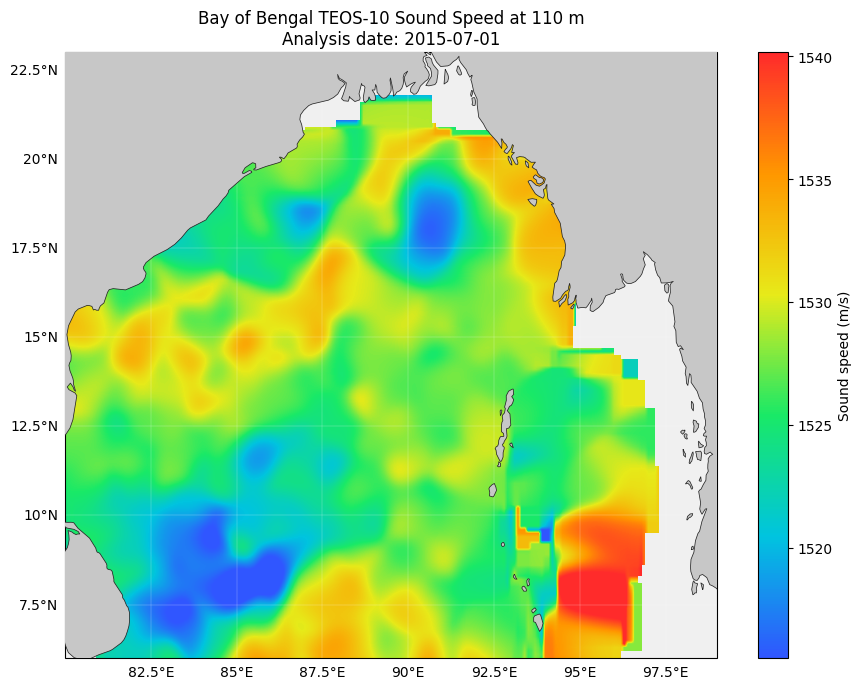

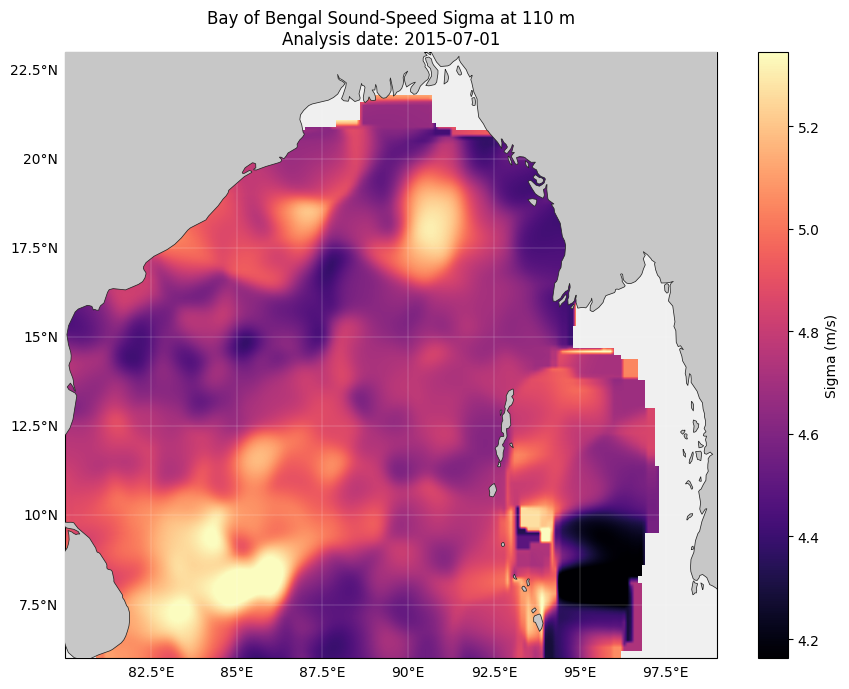

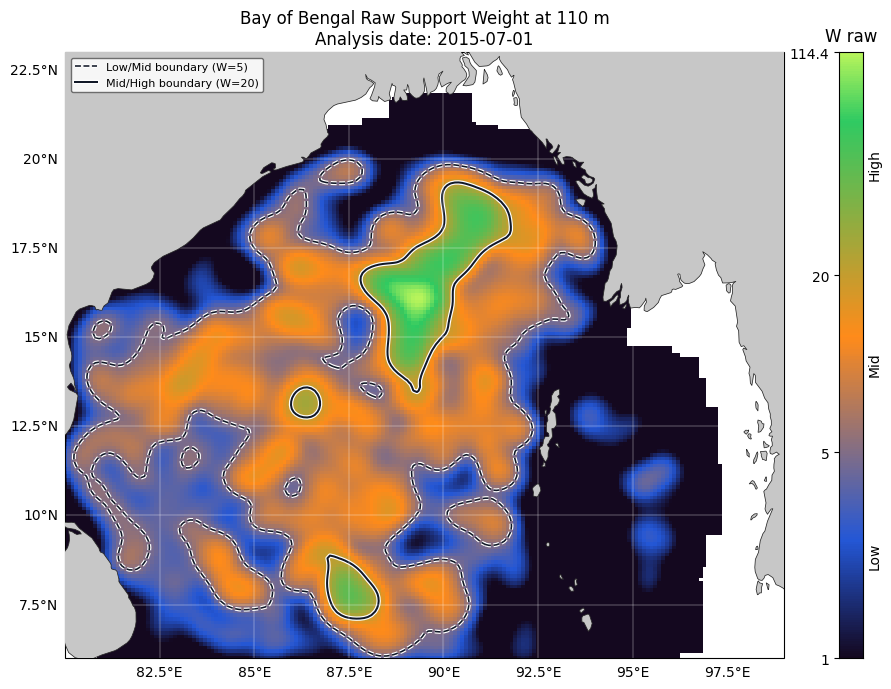

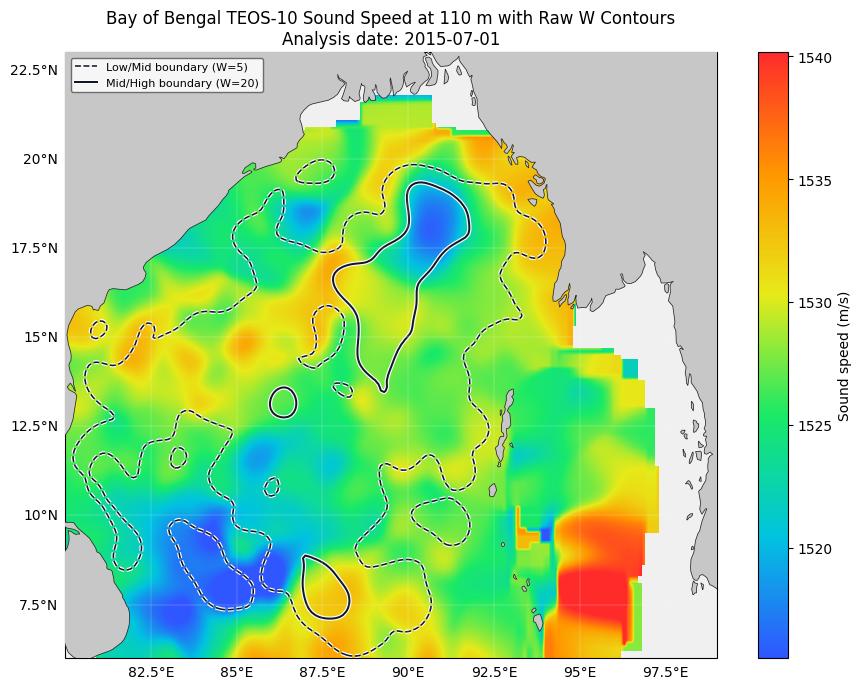

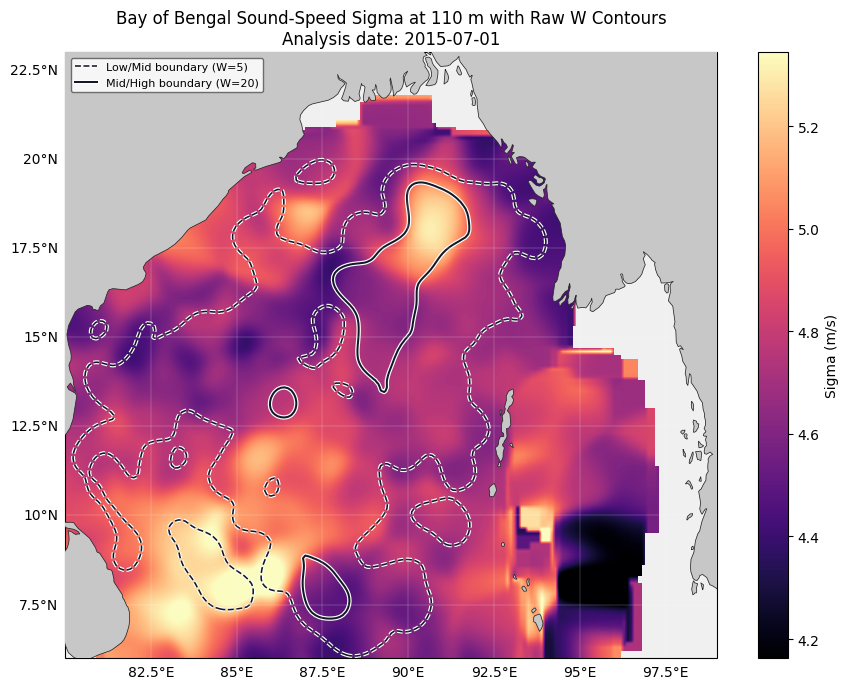

In [12]:
sound_speed_110m = figure_matrices_110m["sound_speed_teos10"]
sigma_sound_speed_110m = figure_matrices_110m["sigma_sound_speed_teos10"]
support_raw_110m = figure_matrices_110m["W_raw"]

support_transparent_threshold = 0.0
support_raw_finite_values = support_raw_110m.to_numpy(dtype=float)
support_raw_finite_values = support_raw_finite_values[np.isfinite(support_raw_finite_values)]
support_raw_positive_values = support_raw_finite_values[support_raw_finite_values > support_transparent_threshold]
support_raw_min_positive = float(np.nanmin(support_raw_positive_values))
support_raw_log_floor = 1.0
support_raw_vmax = float(np.nanmax(support_raw_finite_values))
support_raw_breaks = [support_raw_log_floor, 5.0, 20.0, support_raw_vmax]
support_color_anchor_values = [
    2.5,
    12.5,
    0.5 * (20.0 + support_raw_vmax),
]
support_cluster_labels = [
    ("Low", np.sqrt(support_raw_breaks[0] * support_raw_breaks[1])),
    ("Mid", np.sqrt(support_raw_breaks[1] * support_raw_breaks[2])),
    ("High", np.sqrt(support_raw_breaks[2] * support_raw_breaks[3])),
]
support_norm = mcolors.LogNorm(vmin=support_raw_log_floor, vmax=support_raw_vmax)
support_raw_anchor_positions = [float(support_norm(value)) for value in support_color_anchor_values]
support_cmap = support_region_cmap(
    low_anchor=support_raw_anchor_positions[0],
    mid_anchor=support_raw_anchor_positions[1],
    high_anchor=support_raw_anchor_positions[2],
)
support_contour_levels = [5.0, 20.0]
support_contour_labels = ["Low/Mid boundary (W=5)", "Mid/High boundary (W=20)"]
sound_speed_contour_cmap = mcolors.LinearSegmentedColormap.from_list(
    "sound_speed_contour_hue",
    ["#3056ff", "#00c4df", "#19e967", "#e7ea19", "#ff9700", "#ff2b2b"],
)

sound_speed_limits = (
    float(np.nanquantile(sound_speed_110m.to_numpy(dtype=float), 0.01)),
    float(np.nanquantile(sound_speed_110m.to_numpy(dtype=float), 0.99)),
)
sigma_limits = (
    float(np.nanquantile(sigma_sound_speed_110m.to_numpy(dtype=float), 0.01)),
    float(np.nanquantile(sigma_sound_speed_110m.to_numpy(dtype=float), 0.99)),
)

chart_exports = {}

fig, ax = plot_matrix(
    sound_speed_110m,
    title=chart_title("Bay of Bengal TEOS-10 Sound Speed at 110 m"),
    cbar_label="Sound speed (m/s)",
    cmap=sound_speed_contour_cmap,
    vmin=sound_speed_limits[0],
    vmax=sound_speed_limits[1],
)
chart_exports["sound_speed_teos10_110m"] = save_figure(fig, "sound_speed_teos10_110m")

fig, ax = plot_matrix(
    sigma_sound_speed_110m,
    title=chart_title("Bay of Bengal Sound-Speed Sigma at 110 m"),
    cbar_label="Sigma (m/s)",
    cmap="magma",
    vmin=sigma_limits[0],
    vmax=sigma_limits[1],
)
chart_exports["sigma_sound_speed_teos10_110m"] = save_figure(fig, "sigma_sound_speed_teos10_110m")

fig, ax = plot_support_matrix(
    support_raw_110m,
    title=chart_title("Bay of Bengal Raw Support Weight at 110 m"),
    cbar_label="W raw",
    cmap=support_cmap,
    norm=support_norm,
    colorbar_ticks=support_raw_breaks,
    colorbar_scale="log",
    cluster_labels=support_cluster_labels,
    contour_levels=support_contour_levels,
    contour_labels=support_contour_labels,
    contour_value_label="W raw",
    contour_value_precision=2,
    contour_legend_loc="upper left",
    transparent_threshold=support_transparent_threshold,
    grid_alpha=1.0,
    interpolation="nearest",
)
chart_exports["w_raw_110m"] = save_figure(fig, "w_raw_110m")

fig, ax = plot_matrix_with_support_contours(
    sound_speed_110m,
    support_raw_110m,
    title=chart_title("Bay of Bengal TEOS-10 Sound Speed at 110 m with Raw W Contours"),
    cbar_label="Sound speed (m/s)",
    cmap=sound_speed_contour_cmap,
    vmin=sound_speed_limits[0],
    vmax=sound_speed_limits[1],
    contour_levels=support_contour_levels,
    contour_labels=support_contour_labels,
    contour_value_label="W raw",
    contour_value_precision=2,
    legend_loc="upper left",
)
chart_exports["sound_speed_teos10_w_contours_110m"] = save_figure(
    fig,
    "sound_speed_teos10_w_contours_110m",
)

fig, ax = plot_matrix_with_support_contours(
    sigma_sound_speed_110m,
    support_raw_110m,
    title=chart_title("Bay of Bengal Sound-Speed Sigma at 110 m with Raw W Contours"),
    cbar_label="Sigma (m/s)",
    cmap="magma",
    vmin=sigma_limits[0],
    vmax=sigma_limits[1],
    contour_levels=support_contour_levels,
    contour_labels=support_contour_labels,
    contour_value_label="W raw",
    contour_value_precision=2,
    legend_loc="upper left",
)
chart_exports["sigma_sound_speed_teos10_w_contours_110m"] = save_figure(
    fig,
    "sigma_sound_speed_teos10_w_contours_110m",
)

chart_exports

## Output Paths

In [13]:
{
    "full_uncertainty_product_pickle": uncertainty_product_path,
    "full_uncertainty_product_csv": uncertainty_product_csv_path,
    "uncertainty_product_110m_csv": uncertainty_product_110m_csv_path,
    "uncertainty_depth_summary_csv": uncertainty_depth_summary_csv_path,
    "benchmark_csv": benchmark_path,
    "benchmark_metadata_json": benchmark_metadata_path,
    "spatial_variance_pickle": spatial_variance_path,
    "cycle_model_cache": cycle_model_cache_path,
    "chart_exports": chart_exports,
}

{'full_uncertainty_product_pickle': PosixPath('/home/jcherry/Documents/git/argo-data-interpolation/research/underwater-acoustics/notebooks/data/sound_speed_uncertainty_product.pkl'),
 'full_uncertainty_product_csv': PosixPath('/home/jcherry/Documents/git/argo-data-interpolation/research/underwater-acoustics/notebooks/data/sound_speed_uncertainty_product.csv'),
 'uncertainty_product_110m_csv': PosixPath('/home/jcherry/Documents/git/argo-data-interpolation/research/underwater-acoustics/notebooks/data/sound_speed_uncertainty_product_110m.csv'),
 'uncertainty_depth_summary_csv': PosixPath('/home/jcherry/Documents/git/argo-data-interpolation/research/underwater-acoustics/notebooks/data/sound_speed_uncertainty_depth_summary.csv'),
 'benchmark_csv': PosixPath('/home/jcherry/Documents/git/argo-data-interpolation/research/underwater-acoustics/notebooks/data/sound_speed_uncertainty_benchmark.csv'),
 'benchmark_metadata_json': PosixPath('/home/jcherry/Documents/git/argo-data-interpolation/researc